# Honeycomb Tight-Binding Model

Let's setup the problem class using the honeycomb data json.

In [1]:
from topological_insulator import Problem

data_path = "../../topological_insulator/data/"
file_name = "honeycomb.json"

problem = Problem(data_path=data_path, file_name=file_name)

In [2]:
import numpy as np

subs = ["A", "B"]
for sub_label in subs:
    parser = getattr(problem.cell_parser.eigenvalues, sub_label).value
    try:
        parser["SO_coupling"][sub_label]["lambda_ss"] = 0.1
        parser["SO_coupling"][sub_label]["lambda_sp"] = 0.15
        parser["SO_coupling"][sub_label]["lambda_pp"] = 0.3
        pass
    except:
        pass
    for nn_label in subs:
        if sub_label == nn_label:
            continue
        parser["nn_hopping"][nn_label]["t_ss_sigma"] = -np.sqrt(2)
        parser["nn_hopping"][nn_label]["t_sp_sigma"] = 1
        parser["nn_hopping"][nn_label]["t_pp_sigma"] = 1
        parser["nn_hopping"][nn_label]["t_pp_pi"] = -2

In [3]:
location = "bulk"
problem.setup(
    N_r = 10,            # size of lattice in real space
    N_k = 300,           # reciprocal space discretization
    location = location  # location of where to calculate eigenvalues
)

Building Geometry...
Geometry - Done.
Building 'Bulk' Hamiltonian...
'Bulk' Hamiltonian - Done.


## Clebsch-Gordan Coefficients

In [4]:
tb = problem.hamiltonian[location]["tight_binding"]
tb.sublattice_data_dict["A"].keys()
sublattice = list(tb.sublattice_data_dict["A"].keys())[0]

## Coupled Angular Momentum States

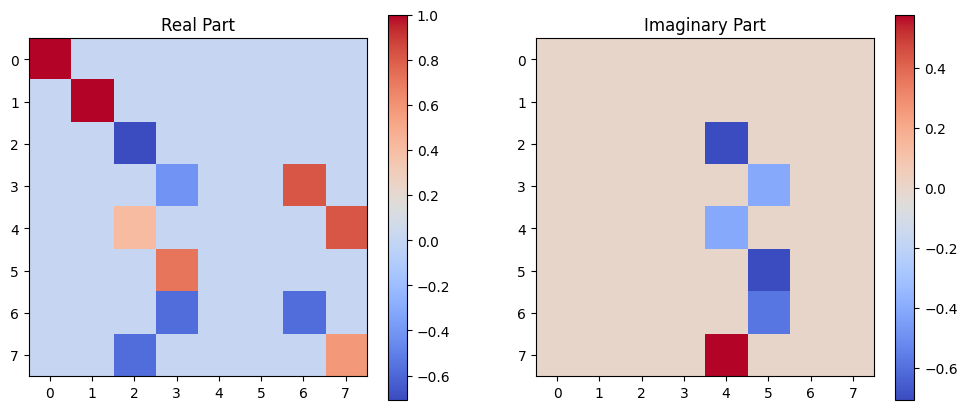

In [5]:
tb._visualise_matrix(tb.U)

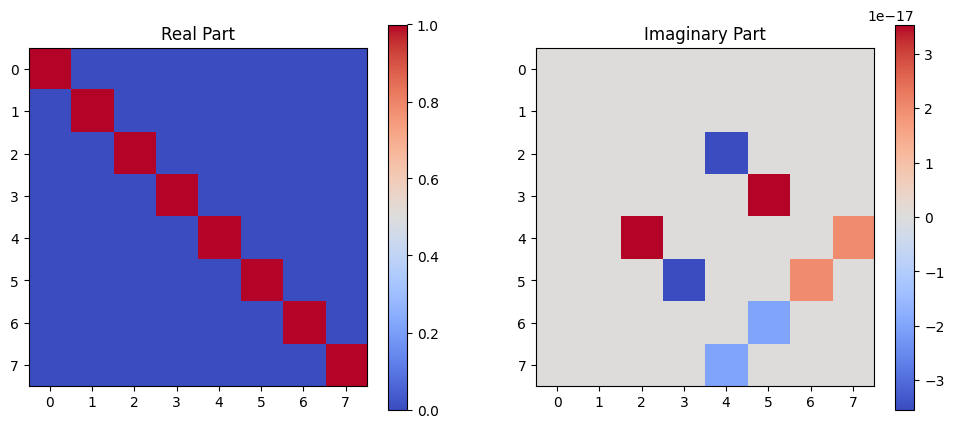

In [6]:
tb._visualise_matrix(tb.U.conj().T@tb.U)

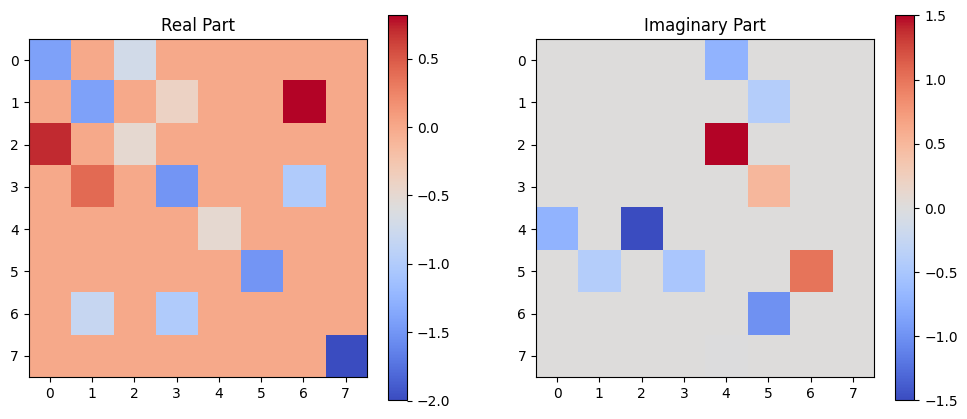

In [7]:
idx = tb.sublattice_data_dict["A"]["NN_idxs"][0]
tb._visualise_matrix(tb.sublattice_data_dict["A"]['hopping_dict'][idx])

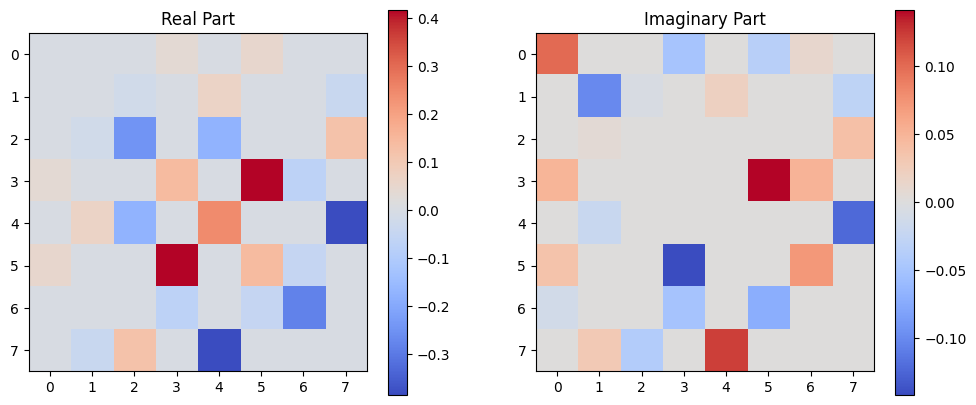

In [8]:
idx = tb.sublattice_data_dict["A"]["NNN_idxs"][0]
tb._visualise_matrix(tb.sublattice_data_dict["A"]['spin_orbit_coupling_dict'][idx])